# EUROPEAN CALL OPTION WITH LOCAL VOLATILITY VIA DUPIRE PDE

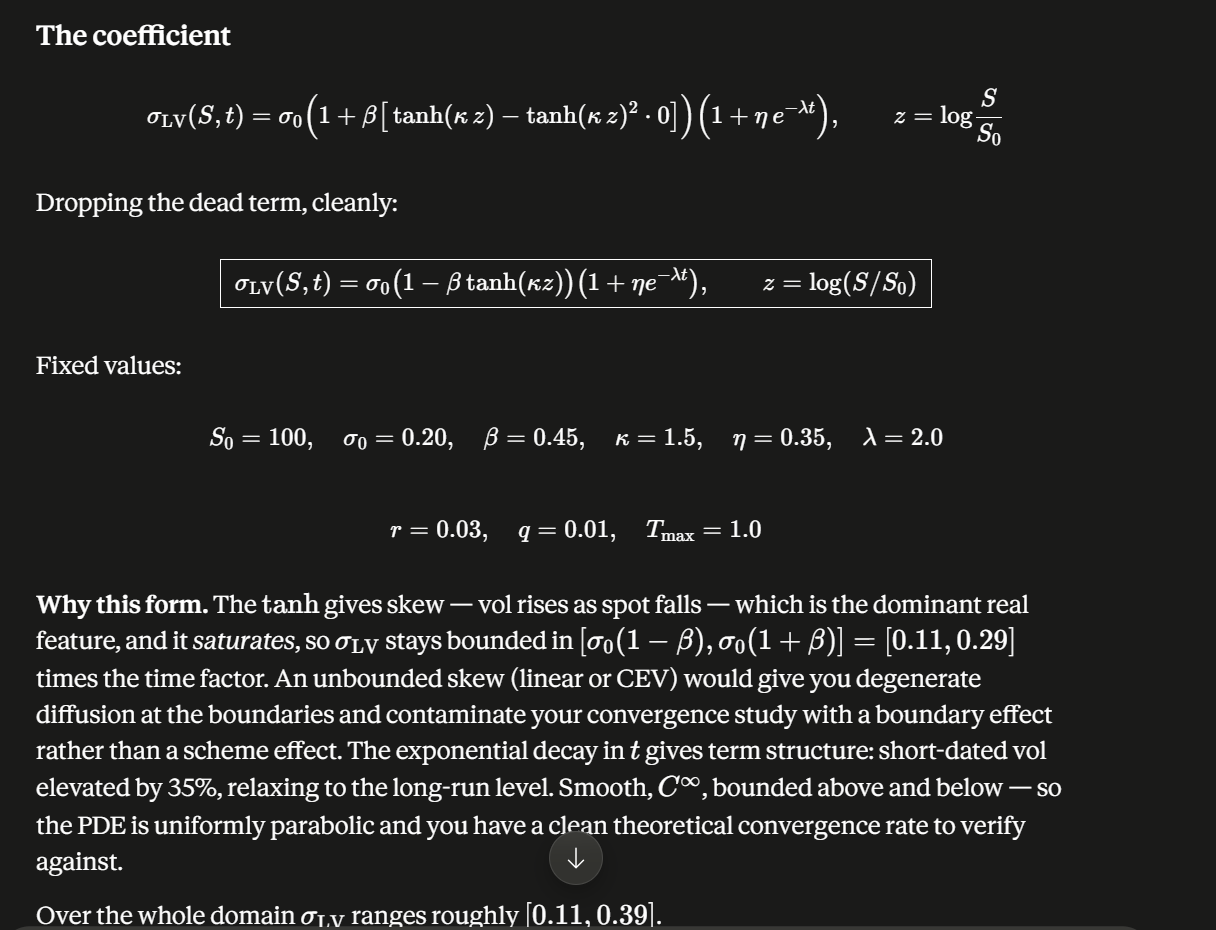

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

In [2]:
S0, sig0, beta, kappa, eta, lam = 100.0, 0.20, 0.45, 1.5, 0.35, 2.0

r, q, Tmax = 0.03, 0.01, 1.0

#beta, eta = 0., 0. #this gives sigma = sig0 fixed for all times and strikes

def sigma_lv(S, t):
    z = np.log(np.asarray(S, float)/S0)
    return sig0*(1.0 - beta*np.tanh(kappa*z))*(1.0 + eta*np.exp(-lam*t))

Dupire PDE in $(K, T)$

$$ \partial_T C = \frac{1}{2} \sigma^2 K^2 \partial^2_K C - (r-q)K \partial_K C - qC$$

$$ C(K,0) = max(S_0 - K, 0), \quad C(0, T) = S_0 e^{-qT}, \quad C(K_{max}, T) = 0$$

In [3]:
w = 1.5

In [4]:
#range of K's covered

S0*np.exp(-w), S0*np.exp(w)

(22.313016014842983, 448.1689070338065)

Make coordinate transformation $x = ln(K/S_0)$

$$ \partial_T C = \frac{1}{2}\sigma^2 \left(\partial^2_x C - \partial_x C \right) - (r - q)\partial_x C - qC $$

$$ C(x, 0 ) = max(S_0 - S_0 e^x, 0), \quad C(-w,T) = S_0 e^{-qT} - S_0 e^{-w}e^{-rT}, \quad C(w, T) = 0 $$


## Load in Chebyshev polynomials and match to initial data

In [5]:
n = 50

diff = np.loadtxt('../diffmatrix100.txt')[0:n,0:n]

chebyshevs = []
for i in range(0, n):
    chebyshevs.append(scipy.special.chebyt(i))

In [6]:
# T array

T = np.linspace(0, Tmax, int(Tmax/10**-3 + 1))
dT = T[1:] - T[0:-1]

# solution array

c = np.zeros((len(T), 2*n))

In [7]:
# transform to two numerical coordinates

def xnum_to_xleft(xnum):
    return (xnum - 1.)*(w/2) 

def xnum_to_xright(xnum):
    return (xnum + 1.)*(w/2)

In [8]:
def get_coeff(n, f, xnum_to_x):

    xcol = np.cos(np.pi*np.linspace(0, n-1, n)/(n-1))
    x = xnum_to_x(xcol)

    L = np.zeros((n,n))
    R = np.zeros(n)

    for i in range(0,n):
        for k in range(0,n):
            L[i, k ] = chebyshevs[k](xcol[i])
            R[i] = f(x[i])
    
    c = np.linalg.solve(L, R)
    return c


In [9]:
# match to initial data using 2 cells

#first cell

fID_left = lambda x: S0*(1 - np.exp(x))

c[0,0:n] = get_coeff(n, fID_left, xnum_to_xleft)

#second cell

fID_right = lambda x: 0.

c[0,n:] = get_coeff(n, fID_right, xnum_to_xright)

In [58]:
# functions to plot data

xplot = np.linspace(-1,1,101)

def calc_u(c,x):
    sum = 0.0
    for i in range(len(c)):
        sum = sum + c[i]*chebyshevs[i](x)
    return sum

def plot_frame(T_index):

    #left part
  
    plt.plot(S0*np.exp(xnum_to_xleft(xplot)), calc_u(c[T_index,0:n], xplot), c='blue')
       
    #right part
   
    plt.plot(S0*np.exp(xnum_to_xright(xplot)), calc_u(c[T_index,n:], xplot), c='blue')
       
    plt.axvline(x = S0, c='black', linewidth=1)
   
    plt.title('f(x) at '+r'T= '+str(T[T_index]))
    plt.ylabel(r'$C_T$')
    plt.xlabel(r'$K$')
    plt.show()

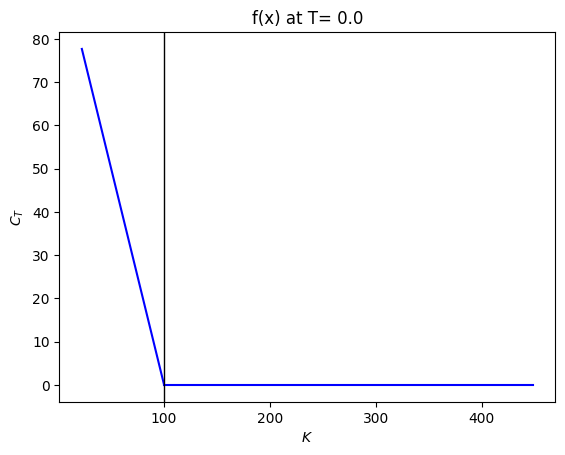

In [59]:
plot_frame(0)

## Transform PDE Problem to 2-chebyshev cell coordinates

$$ \partial_T C = \frac{1}{2} \sigma^2 \left( \frac{2}{w} \right)^2 \partial^2_{xnum} C  - \left( \frac{1}{2}\sigma^2 + (r-q)\right)\frac{2}{w}\partial_{xnum} C - qC  = 0 $$

$$ C(T, xnumleft =+1)  - C(T, xnumright = -1)  = 0$$

$$ \frac{2}{w}\partial_{xnumleft} C(T, xnumleft =+1) - \frac{2}{w}\partial_{xnumright} C(T, xnumright =-1) = 0$$

$$ C(T, xnumleft=-1) - \left( S_0 e^{-qT} - S_0 e^{-(w - rT)} \right)= 0$$

$$ C(T, xnumright = 1) = 0 $$

## Method of Lines Solution with SDIRK

In [16]:
a11 = 4.772644573858262e-01
c1 = a11

a21 = -1.970525884150017e-01
a22 = 4.763634284595835e-01
c2 = a21 + a22

a31 = -3.476744303729656e-02
a32 = 6.330518073354831e-01
a33 = 1.936343100750279e-01
c3 = a31 + a32 + a33

a41 = 9.677976685787021e-02
a42 = -1.935335264665350e-01
a43 = -2.076229458004729e-04
a44 = 1.595722048494314e-01
c4 = a41 + a42 + a43 + a44

a51 = 1.625272318198749e-01
a52 = -2.496725135473825e-01
a53 = -4.590799720417948e-02
a54 = 3.657947640085904e-01
a55 = 2.557528383076989e-01
c5 = a51 + a52 + a53 + a54 + a55

a61 = -7.076031971712624e-03
a62 = 8.462998548602952e-01
a63 = 3.440200169250181e-01
a64 = -7.209260545488652e-02
a65 = -2.154923319808753e-01
a66 = 1.043410976221611e-01
c6 = a61 + a62 + a63 + a64 + a65 + a66


a71 = 1.768579351797444e-03
a72 = 7.799600131275149e-02
a73 = 3.033332775645574e-01
a74 = 2.131608067328356e-01
a75 = 3.517693203190381e-01
a76 = -3.815458943865381e-01
a77 = 4.335179091055582e-01
c7 = a71 + a72 + a73 + a74 + a75 + a76 + a77

a81 = 0.000000000000000e+00
a82 = 2.273235341055902e-01
a83 = 3.084158379801177e-01
a84 = 1.572634195730069e-01
a85 = 2.435511371522748e-01
a86 = -1.209536267328315e-01
a87 = -8.026784733998993e-02
a88 =  2.646675452618318e-01
c8 = a81 + a82 + a83 + a84 + a85 + a86 + a87 + a88

b1 = a81
b2 = a82
b3 = a83
b4 = a84
b5 = a85
b6 = a86
b7 = a87
b8 = a88



In [17]:
def calc_T_matrix(dim, xcol):
    T = np.zeros(dim)
    for i in range(0,dim):
        T[i] = chebyshevs[i](xcol)
    return T

#Gauss-Lobatto Nodes
xcol = np.cos(np.pi*np.linspace(1, n-2, int(n-3/1 + 1))/(n-1))

#collocation matrices
Tcol = np.zeros((len(xcol),n))
for i in range(0, len(xcol)):
    Tcol[i,:] = calc_T_matrix(n, xcol[i])
    
Tdiffcol = np.matmul(Tcol, diff)
Tdiff2col = np.matmul(np.matmul(Tcol, diff), diff)

In [18]:
def calc_K(c, T_inp, dT_inp, K1, K2, K3, K4, K5, K6, K7, key):

    dT = dT_inp

    if key == 1:
        T = T_inp + dT*c1
    elif key == 2:
        T = T_inp + dT*c2
    elif key == 3:
        T = T_inp + dT*c3
    elif key == 4:
        T = T_inp + dT*c4
    elif key == 5:
        T = T_inp + dT*c5
    elif key == 6:
        T = T_inp + dT*c6
    elif key == 7:
        T = T_inp + dT*c7
    elif key == 8:
        T = T_inp + dT*c8
    

    L = np.zeros((2*n, 2*n))
    R = np.zeros((2*n, 2*n))
    J = np.zeros((2*n))
        
    #prepare the matrices
    
###################################################################################################
  
    #left outermost

    L[0:len(xcol),0:n] = Tcol 
    sigma_lv_vals = sigma_lv(S0*np.exp(xnum_to_xleft(xcol)),T)
    R[0:len(xcol),0:n] = (1/2)*(2/w)**2*(sigma_lv_vals**2.*Tdiff2col.T).T - (2/w)*((0.5*sigma_lv_vals**2. +(r-q))*Tdiffcol.T).T + (-q)*Tcol
    
    row_count = len(xcol)    
    
#####################################################################################################################################
    
   
    #right outermost cell
    
    L[row_count:row_count + len(xcol),n:] = Tcol 
    sigma_lv_vals = sigma_lv(S0*np.exp(xnum_to_xright(xcol)),T)
    R[row_count:row_count + len(xcol),n:] = (1/2)*(2/w)**2*(sigma_lv_vals**2.*Tdiff2col.T).T - (2/w)*((0.5*sigma_lv_vals**2. +(r-q))*Tdiffcol.T).T + (-q)*Tcol

    row_count = row_count + len(xcol)
    
#############################################################################################################################################
    
    #boundary conditions

    #left cell
    R[row_count, 0:n] = calc_T_matrix(n, -1.)
    J[row_count] = S0*np.exp(-q*T) - S0*np.exp(-(w + r*T))

    row_count = row_count + 1

    #right cell
    R[row_count, n:] = calc_T_matrix(n, +1.) 
    J[row_count] =  0.

    row_count = row_count + 1
    
    
####################################################################################################################################################
    

    #interface conditions
    TL = calc_T_matrix(n, +1.0)
    TR = calc_T_matrix(n, -1.0)
    TLdiff = np.matmul(TL, diff) 
    TRdiff = np.matmul(TR, diff) 

    #continuity
    
    R[row_count, 0:n] = -1*TL
    R[row_count, n:] = 1*TR
        
    row_count = row_count + 1
    
   
    #differentiability

    R[row_count, 0:n] = -(2/w)*TLdiff 
    R[row_count, n: ] = +(2/w)*TRdiff
    
    row_count = row_count + 1
    
    if key == 1:
        Lbar = L - R*(dT)*(a11)
        Rbar = np.matmul(R, c) - J
        K1 = np.linalg.solve(Lbar,Rbar)
        return K1
    elif key == 2:
        Lbar = L - R*(dT)*(a22)
        Rbar = np.matmul(R, c + dT*K1*a21) - J
        K2 = np.linalg.solve(Lbar,Rbar)
        return K2
    elif key == 3:
        Lbar = L - R*(dT)*(a33)
        Rbar = np.matmul(R, c + dT*K1*a31 + dT*K2*a32) - J
        K3 = np.linalg.solve(Lbar,Rbar)
        return K3
    elif key == 4:
        Lbar = L - R*(dT)*(a44)
        Rbar = np.matmul(R, c + dT*K1*a41 + dT*K2*a42 + dT*K3*a43) - J
        K4 = np.linalg.solve(Lbar,Rbar)
        return K4
    elif key == 5:
        Lbar = L - R*(dT)*(a55)
        Rbar = np.matmul(R, c + dT*K1*a51 + dT*K2*a52 + dT*K3*a53 + dT*K4*a54) - J
        K5 = np.linalg.solve(Lbar,Rbar)
        return K5
    elif key == 6:
        Lbar = L - R*(dT)*(a66)
        Rbar = np.matmul(R, c + dT*K1*a61 + dT*K2*a62 + dT*K3*a63 + dT*K4*a64 + dT*K5*a65) - J
        K6 = np.linalg.solve(Lbar,Rbar)
        return K6
    elif key == 7:
        Lbar = L - R*(dT)*(a77)
        Rbar = np.matmul(R, c + dT*K1*a71 + dT*K2*a72 + dT*K3*a73 + dT*K4*a74 + dT*K5*a75 + dT*K6*a76) - J
        K7 = np.linalg.solve(Lbar,Rbar)
        return K7
    elif key == 8:
        Lbar = L - R*(dT)*(a88)
        Rbar = np.matmul(R, c + dT*K1*a81 + dT*K2*a82 + dT*K3*a83 + dT*K4*a84 + dT*K5*a85 + dT*K6*a86 + dT*K7*a87) - J
        K8 = np.linalg.solve(Lbar,Rbar)
        return K8
    

In [19]:
#Calculate Data for all Times

for i in range(0, len(T)-1):
    K1 = calc_K(c[i,:],T[i], dT[i], None, None, None, None, None, None, None, 1)
    K2 = calc_K(c[i,:],T[i], dT[i], K1, None, None, None, None, None, None, 2)
    K3 = calc_K(c[i,:],T[i], dT[i], K1, K2, None, None, None, None, None, 3)
    K4 = calc_K(c[i,:],T[i], dT[i], K1, K2, K3, None, None, None, None, 4)
    K5 = calc_K(c[i,:],T[i], dT[i], K1, K2, K3, K4 , None, None, None, 5)
    K6 = calc_K(c[i,:],T[i], dT[i], K1, K2, K3, K4 , K5, None, None, 6)
    K7 = calc_K(c[i,:],T[i], dT[i], K1, K2, K3, K4 , K5, K6, None, 7)
    K8 = calc_K(c[i,:],T[i], dT[i], K1, K2, K3, K4 , K5, K6, K7, 8)

    c[i+1,:] = c[i,:] + dT[i]*(b1*K1 + b2*K2 +b3*K3 + b4*K4 + b5*K5 + b6*K6 + b7*K7 + b8*K8)
    
    if i%100==0:
        print(i)
        print('The time is: '+str(T[i]))
        print('The average of the Chebychev coefficients is: '+str(np.mean(np.abs(c[i,:]))))

0
The time is: 0.0
The average of the Chebychev coefficients is: 0.9176695615930096
100
The time is: 0.1
The average of the Chebychev coefficients is: 0.9463532344790108
200
The time is: 0.2
The average of the Chebychev coefficients is: 0.9525810952710013
300
The time is: 0.3
The average of the Chebychev coefficients is: 0.9570073063605626
400
The time is: 0.4
The average of the Chebychev coefficients is: 0.9621186137408142
500
The time is: 0.5
The average of the Chebychev coefficients is: 0.9666059226319811
600
The time is: 0.6
The average of the Chebychev coefficients is: 0.970332037297682
700
The time is: 0.7000000000000001
The average of the Chebychev coefficients is: 0.973566274771985
800
The time is: 0.8
The average of the Chebychev coefficients is: 0.9764423014851973
900
The time is: 0.9
The average of the Chebychev coefficients is: 0.9793882358353504


## Analysis

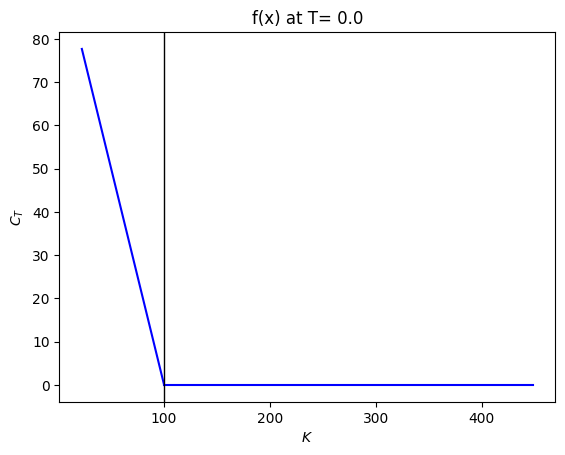

In [60]:
plot_frame(0)

In [21]:
def plot_coeff(T_index):
    plt.plot(np.log10(np.abs(c[T_index, 0:n])), c='red', label = 'left')
    plt.plot(np.log10(np.abs(c[T_index, n:])), c='blue', label = 'right')
    plt.xlabel(r'$k$')
    plt.ylabel(r'$log_{10}|c_k|$')
    plt.legend()
    plt.show()

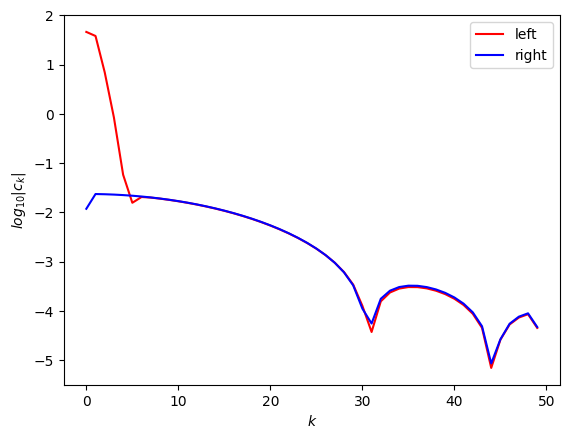

In [22]:
plot_coeff(1)

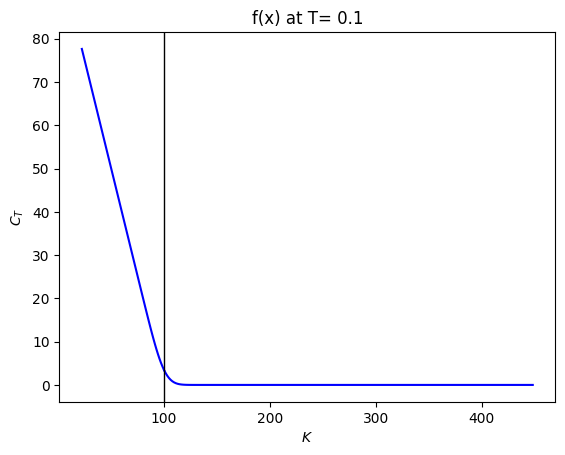

In [61]:
plot_frame(100)

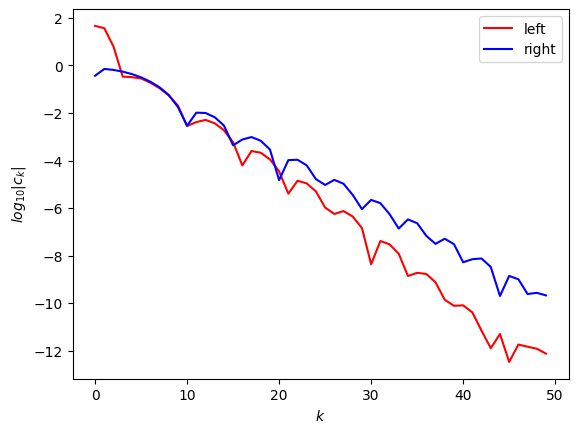

In [24]:
plot_coeff(100)

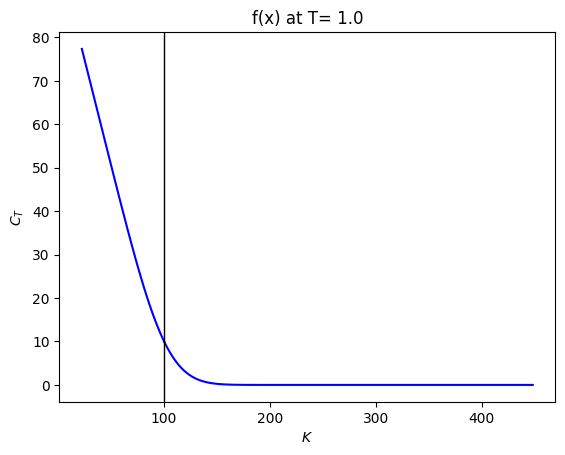

In [62]:
plot_frame(1000)

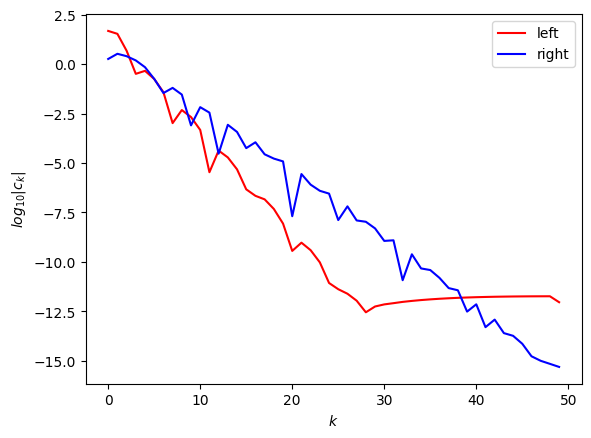

In [26]:
plot_coeff(1000)

In [27]:
def xleft_to_xnum(xleft):
    return (2/w)*xleft + 1.

def xright_to_xnum(xright):
    return (2/w)*xright - 1.

### Value to Compare with the backward solver. This is for any generic $\sigma$

$$ B(S_0, \tau = T^*)_K = F(K, T^*)_{S_0}$$

In [28]:
#when K=120, x= ln(K/100) = ln(120/100) = ln(6/5)
# choose T = 1,  index = -1

print(calc_u(c[-1,n:], xright_to_xnum(np.log(6/5))))

3.047512056968579


## Movie

In [113]:
def plot_frame_movie(index, ax):

    #left part
  
    ax.plot(S0*np.exp(xnum_to_xleft(xplot)), calc_u(c[index,0:n], xplot), c='blue')
       
    #right part
   
    ax.plot(S0*np.exp(xnum_to_xright(xplot)), calc_u(c[index,n:], xplot), c='blue')
    

    
    ax.axvline(x=120, c='red', linestyle='dashed')
    ax.axvline(x=100, c='green', linestyle='dashed')
    ax.annotate(r'$\text{Stock}(S)=100$' ,(150,70), c='green', fontsize=15)
       
    ax.axhline(y=calc_u(c[index,n:], xright_to_xnum(np.log(6/5))), c='red', linestyle='dashed')
    ax.annotate(f'C(K=120,T= {T[index]:.2f}) = {calc_u(c[index,n:], xright_to_xnum(np.log(6/5))):.2f}', (150, 10), c='red', fontsize=15)

    ax.set_xlabel(r'$\text{Strike Price}(K)$', fontsize=20)
    ax.set_ylabel(r'$\text{Call Price}(C)$', fontsize=20)
    ax.set_title('Dupire PDE', fontsize=20)
    ax.grid()

  
    

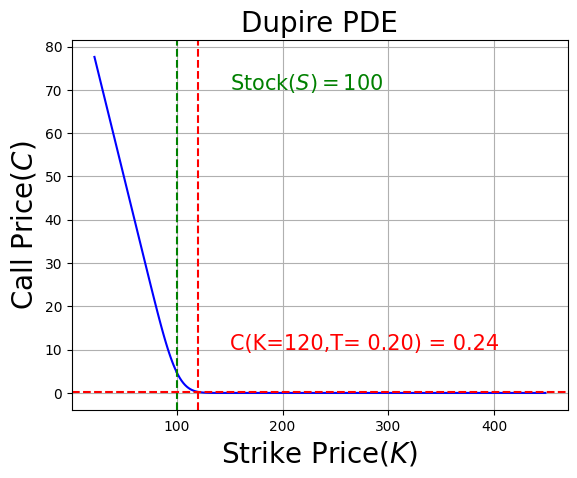

In [114]:
fig, ax = plt.subplots()
plot_frame_movie(200,ax)
plt.show()

In [115]:
from matplotlib.animation import PillowWriter

In [116]:
metadata = dict(title='Movie', artist ='ayush_roy')
writer = PillowWriter(fps=10, metadata = metadata)

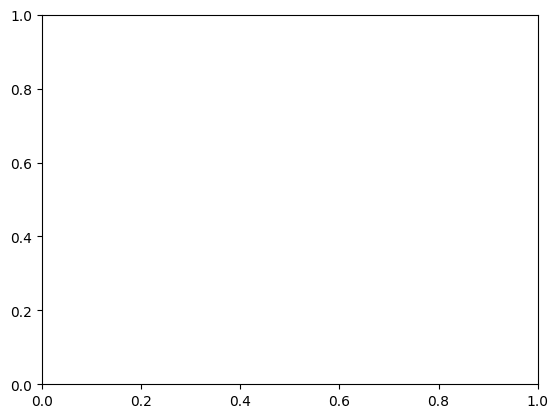

In [117]:
fig, ax = plt.subplots()

with writer.saving(fig, 'dupire_pde.gif',100):
    for i in range(0, len(T)):
        if i%4 == 0:
            plot_frame_movie(i, ax)
            writer.grab_frame()
            ax.clear()
        if i == len(T)-1:
            for j in range(0,30):
                plot_frame_movie(i, ax)
                writer.grab_frame()
                ax.clear()


### Heatmap of errors with fixed N and timestep. This is for when $\sigma = \sigma_0$

In [24]:

def euro_call(S, K, T, r, q, sig):
    d1 = (np.log(S/K) + (r-q+0.5*sig**2)*T)/(sig*np.sqrt(T))
    d2 = d1 - sig*np.sqrt(T)
    return S*np.exp(-q*T)*scipy.stats.norm.cdf(d1) - K*np.exp(-r*T)*scipy.stats.norm.cdf(d2)

In [26]:
# heatmap of errors

#pass in solution array

def call_heatmap(c):

    numerical_solution = np.zeros((len(T), 2*len(xplot)))
    analytical_solution = np.zeros((len(T), 2*len(xplot)))

    for i in range(0, len(T)):
        numerical_solution[i,:len(xplot)] = calc_u(c[i,0:n], xplot)
        analytical_solution[i,:len(xplot)] = euro_call(S0, S0*np.exp(xnum_to_xleft(xplot)), T[i], r, q, sigma_lv(S0, 0.))
        
        numerical_solution[i,len(xplot):] = calc_u(c[i,n:], xplot)
        analytical_solution[i,len(xplot):] = euro_call(S0, S0*np.exp(xnum_to_xright(xplot)), T[i], r, q, sigma_lv(S0, 0.))
        
    errors = np.abs(numerical_solution - analytical_solution)

    return numerical_solution, analytical_solution, errors

In [27]:
num_call, ana_call, errors_call = call_heatmap(c)

C:\Users\Ayush Roy\AppData\Local\Temp\ipykernel_14140\2479393820.py:2: RuntimeWarning: divide by zero encountered in divide
  d1 = (np.log(S/K) + (r-q+0.5*sig**2)*T)/(sig*np.sqrt(T))
C:\Users\Ayush Roy\AppData\Local\Temp\ipykernel_14140\2479393820.py:2: RuntimeWarning: invalid value encountered in divide
  d1 = (np.log(S/K) + (r-q+0.5*sig**2)*T)/(sig*np.sqrt(T))


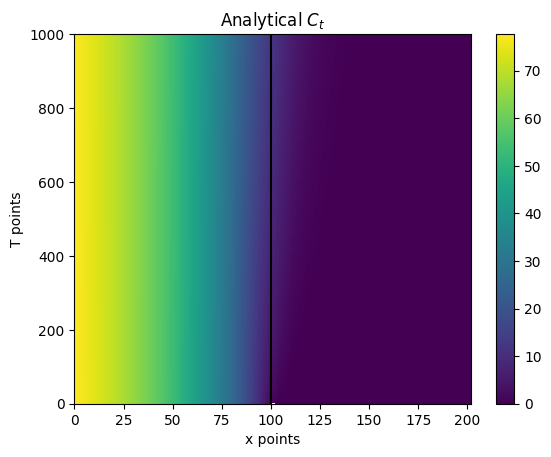

In [28]:
plt.pcolormesh(ana_call)
plt.title('Analytical '+r'$C_t$')
plt.xlabel('x points')
plt.ylabel(r'T '+'points')
plt.axvline(x=100, c='black')
plt.colorbar()

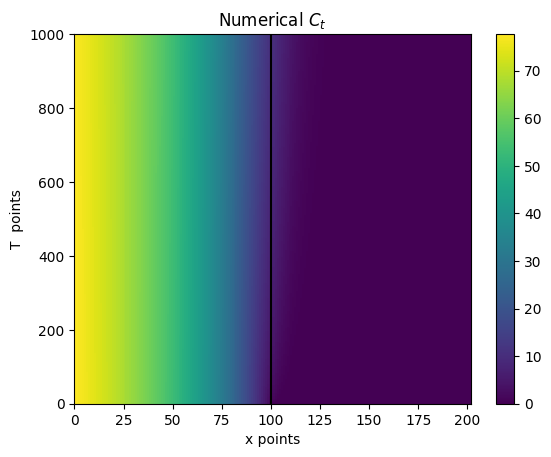

In [29]:
plt.pcolormesh(num_call)
plt.title('Numerical '+r'$C_t$')
plt.xlabel('x points')
plt.ylabel(r'T '+' points')
plt.axvline(x=100, c='black')
plt.colorbar()

C:\Users\Ayush Roy\AppData\Local\Temp\ipykernel_14140\3183702969.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(np.log10(errors_call))


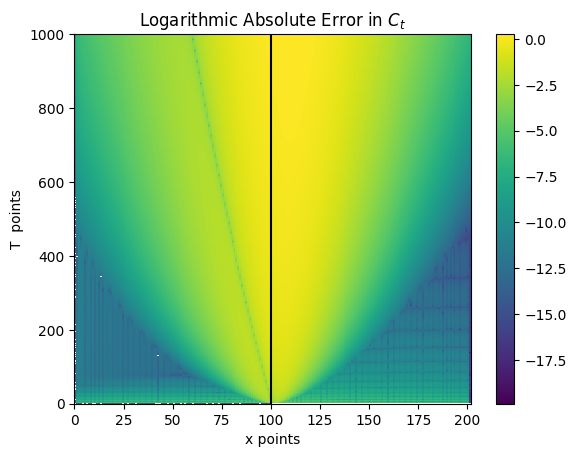

In [30]:
plt.pcolormesh(np.log10(errors_call))
plt.title('Logarithmic Absolute Error in '+r'$C_t$')
plt.xlabel('x points')
plt.ylabel(r'T '+' points')
plt.axvline(x=100, c='black')
plt.colorbar()